# NPS DVCS Acceptance Analysis
## π0 Exclusive Photoproduction Simulation Study

This notebook analyzes GEANT4/SIMC simulation data for exclusive π0 production to calculate NPS acceptance efficiency based on cluster position patterns and geometrical cuts.

## Section 1: Import Required Libraries

We'll use ROOT for data I/O, NumPy for numerical operations, Matplotlib for visualization, and pandas for data management.

In [100]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LogNorm
import uproot
import awkward as ak
from pathlib import Path

# Configuration for plots
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 2: Load ROOT File and Extract Tree

Load the GEANT4/SIMC simulation file and extract the event tree containing cluster and photon hit data.

In [101]:
# Path to simulation file
root_file_path = "/work/hallc/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_pi0_x60_4b_geant_500k.root"

# Check file exists
if Path(root_file_path).exists():
    print(f"✓ ROOT file found: {root_file_path}")
else:
    print(f"✗ ROOT file NOT found: {root_file_path}")
    raise FileNotFoundError(f"Simulation file not found at {root_file_path}")

# Open ROOT file and load tree
print("\nOpening ROOT file...")
root_file = uproot.open(root_file_path)
print(f"Available keys: {list(root_file.keys())}")

# Extract the tree (typically named 'nerd' for NPS event records)
tree_name = "nerd"
if tree_name in root_file:
    tree = root_file[tree_name]
    print(f"✓ Tree '{tree_name}' loaded successfully")
else:
    # Try to find any tree in the file
    tree_keys = [k for k in root_file.keys() if 'tree' in k.lower() or 'evt' in k.lower()]
    if tree_keys:
        tree_name = tree_keys[0]
        tree = root_file[tree_name]
        print(f"✓ Found tree: '{tree_name}'")
    else:
        print(f"Available objects: {list(root_file.keys())}")
        raise KeyError("Could not find event tree in ROOT file")

# Print tree info
print(f"\nTree branches ({len(tree.keys())} total):")
branch_list = list(tree.keys())[:10]  # Show first 10
for branch in branch_list:
    print(f"  - {branch}")
if len(tree.keys()) > 10:
    print(f"  ... and {len(tree.keys()) - 10} more branches")

total_events = tree.num_entries
print(f"\nTotal events in tree: {total_events:,}")

✓ ROOT file found: /work/hallc/nps/singhav/geant4_simc/HallC_NPS/DVCS_evt_gen/DVCS/nps_excl_pi0_x60_4b_geant_500k.root

Opening ROOT file...
Available keys: ['nerd;16', 'nerd;15']
✓ Tree 'nerd' loaded successfully

Tree branches (103 total):
  - evtNb
  - edep
  - phot1_hit
  - phot1_vx
  - phot1_vy
  - phot1_vz
  - phot1_hit_x
  - phot1_hit_y
  - phot1_hit_z
  - phot1_clust_x
  ... and 93 more branches

Total events in tree: 500,000


In [102]:
# Extract needed branches for analysis
print("Loading data from tree...")

# Define branches we need
branches_to_load = [
    "clust_X", "clust_Y", "clust_E",  # Cluster positions and energy (JAGGED ARRAYS - one per cluster)
    "phot1_hit", "phot2_hit",          # Photon hit flags (one per event)
    "nClusters"                        # Number of clusters (one per event)
]

# Load data - note that clust_X, clust_Y, clust_E are jagged arrays (one value per cluster per event)
# We'll flatten these to create a cluster-level DataFrame (matching ROOT's tree->Draw behavior)
print("\nLoading branches:")

jagged_branches = ["clust_X", "clust_Y", "clust_E"]
event_branches = ["phot1_hit", "phot2_hit", "nClusters"]

# First, load jagged branches using awkward arrays for proper handling
jagged_data = {}
event_data = {}

for branch in jagged_branches:
    if branch in tree.keys():
        raw_data = tree[branch].array(library="ak")  # Use awkward array library
        print(f"  {branch}: {len(raw_data)} events, total {ak.count(raw_data, axis=None)} values")
        jagged_data[branch] = raw_data
    else:
        print(f"  ✗ {branch} not found")

# Load event-level branches
for branch in event_branches:
    if branch in tree.keys():
        raw_data = tree[branch].array(library="np")
        print(f"  {branch}: {len(raw_data)} events")
        event_data[branch] = raw_data
    else:
        print(f"  ✗ {branch} not found")

# Now flatten the jagged arrays efficiently using awkward operations
# This matches ROOT's tree->Draw("clust_X") which draws all cluster values
print("\nFlattening jagged arrays (using vectorized operations):")

# Flatten each jagged branch using ak.flatten() - much faster than loops
flattened_data = {}
for branch in jagged_branches:
    flat = ak.flatten(jagged_data[branch], axis=None)  # Flatten all dimensions
    flattened_data[branch] = np.asarray(flat, dtype=np.float64)  # Convert to numpy

# Create event indices by computing cumulative counts
# This tells us which event each cluster belongs to
counts = ak.count(jagged_data["clust_X"], axis=1)  # clusters per event
event_indices = np.repeat(np.arange(len(counts)), counts)

print(f"Total events: {len(event_data['nClusters'])}")
print(f"Total clusters (flattened): {len(event_indices)}")

# Create DataFrame at cluster level (one row per cluster)
df = pd.DataFrame(flattened_data)
df["event_idx"] = event_indices

# Add event-level properties to each cluster row (replicate for each cluster in the event)
for branch in event_branches:
    df[branch] = event_data[branch][event_indices]

print(f"\nDataFrame created with {len(df)} clusters (from {len(event_data['nClusters'])} events)")
print(f"\nData summary:")
print(df.describe())

Loading data from tree...

Loading branches:
  clust_X: 500000 events, total 644066 values
  clust_Y: 500000 events, total 644066 values
  clust_E: 500000 events, total 644066 values
  phot1_hit: 500000 events
  phot2_hit: 500000 events
  nClusters: 500000 events

Flattening jagged arrays (using vectorized operations):
Total events: 500000
Total clusters (flattened): 644066

DataFrame created with 644066 clusters (from 500000 events)

Data summary:
             clust_X        clust_Y        clust_E      event_idx  \
count  644066.000000  644066.000000  644066.000000  644066.000000   
mean        0.042832       0.006576       2.290722  249825.419480   
std        17.378788      20.867898       1.111950  144380.121907   
min       -31.175011     -37.625000       0.208873       0.000000   
25%       -14.140947     -17.170002       1.356139  124877.250000   
50%         0.152485       0.027807       2.182860  249621.500000   
75%        14.186790      17.162716       3.126355  374897.50000

## Diagnostic Plots: Cluster Properties Distribution

Visualize the raw cluster data distributions for clust_X, clust_Y, and clust_E to understand the detector response.

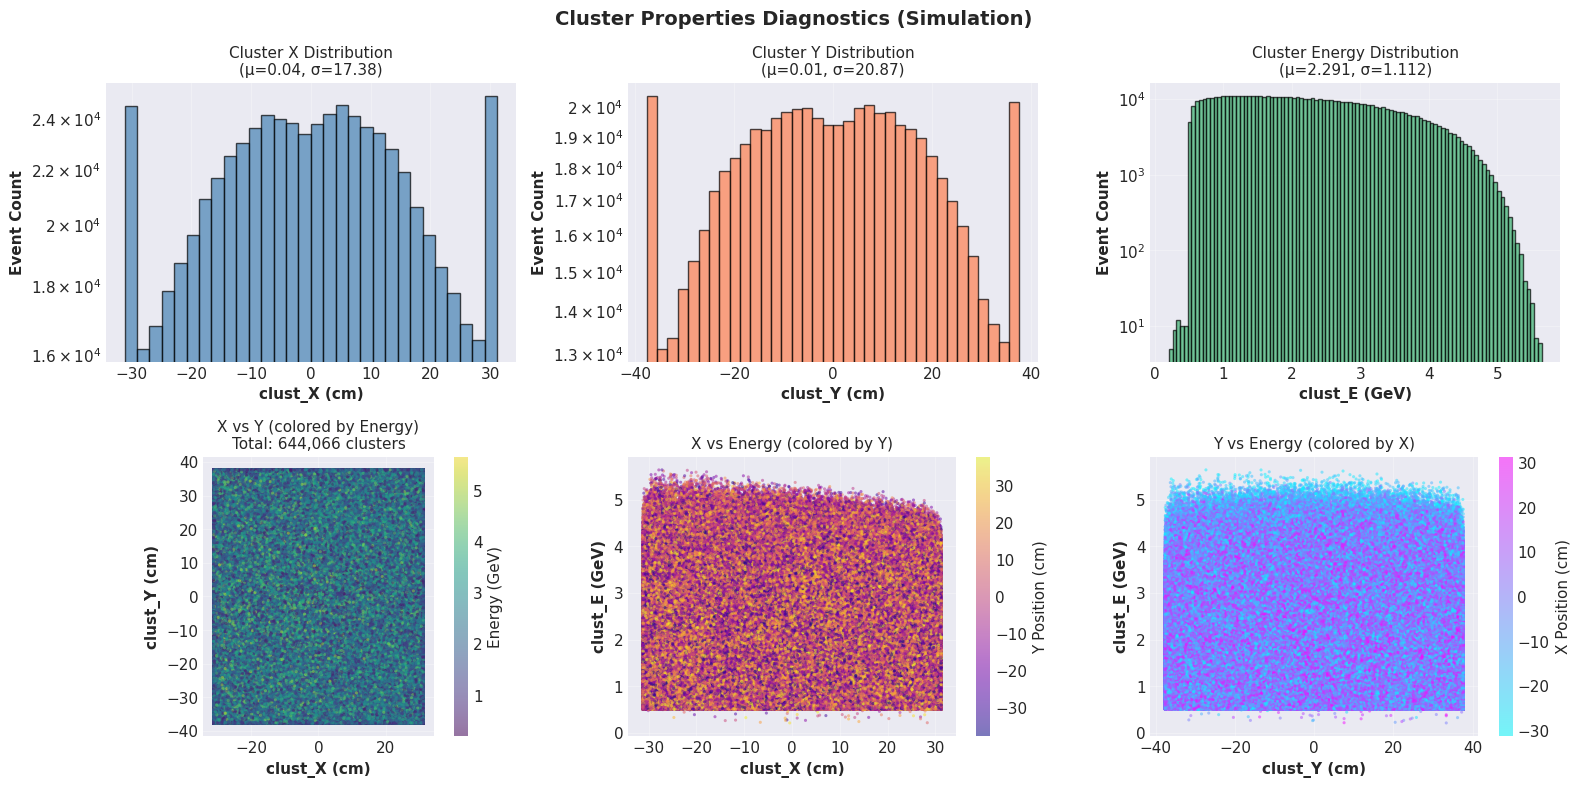


CLUSTER DIAGNOSTICS SUMMARY

Total clusters: 644,066

clust_X Statistics:
  Mean:         0.0428 cm
  Std Dev:     17.3788 cm
  Min:        -31.1750 cm
  Max:         31.1750 cm

clust_Y Statistics:
  Mean:         0.0066 cm
  Std Dev:     20.8679 cm
  Min:        -37.6250 cm
  Max:         37.6250 cm

clust_E Statistics:
  Mean:         2.2907 GeV
  Std Dev:      1.1120 GeV
  Min:          0.2089 GeV
  Max:          5.6426 GeV



In [118]:
# Create diagnostic plots for cluster properties
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Cluster Properties Diagnostics (Simulation)", fontsize=14, fontweight='bold')

# Get valid data and ensure clust_E is numeric
df_diag = df[["clust_X", "clust_Y", "clust_E", "nClusters"]].copy()

# Convert clust_E to numeric type, coercing errors to NaN
df_diag["clust_E"] = pd.to_numeric(df_diag["clust_E"], errors='coerce')
df_diag["clust_X"] = pd.to_numeric(df_diag["clust_X"], errors='coerce')
df_diag["clust_Y"] = pd.to_numeric(df_diag["clust_Y"], errors='coerce')

df_diag = df_diag.dropna()

# Row 1: Histograms
# clust_X histogram
ax = axes[0, 0]
ax.hist(df_diag["clust_X"], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel("clust_X (cm)", fontsize=11, fontweight='bold')
ax.set_ylabel("Event Count", fontsize=11, fontweight='bold')
ax.set_title(f"Cluster X Distribution\n(μ={df_diag['clust_X'].mean():.2f}, σ={df_diag['clust_X'].std():.2f})", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# clust_Y histogram
ax = axes[0, 1]
ax.hist(df_diag["clust_Y"], bins=36, color='coral', alpha=0.7, edgecolor='black')
ax.set_xlabel("clust_Y (cm)", fontsize=11, fontweight='bold')
ax.set_ylabel("Event Count", fontsize=11, fontweight='bold')
ax.set_title(f"Cluster Y Distribution\n(μ={df_diag['clust_Y'].mean():.2f}, σ={df_diag['clust_Y'].std():.2f})", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# clust_E histogram
ax = axes[0, 2]
ax.hist(df_diag["clust_E"], bins=100, color='mediumseagreen', alpha=0.7, edgecolor='black')
ax.set_xlabel("clust_E (GeV)", fontsize=11, fontweight='bold')
ax.set_ylabel("Event Count", fontsize=11, fontweight='bold')
ax.set_title(f"Cluster Energy Distribution\n(μ={df_diag['clust_E'].mean():.3f}, σ={df_diag['clust_E'].std():.3f})", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')

# Row 2: 2D projections
# clust_X vs clust_Y
ax = axes[1, 0]
scatter = ax.scatter(df_diag["clust_X"], df_diag["clust_Y"], c=df_diag["clust_E"], 
                     cmap='viridis', alpha=0.5, s=5, edgecolors='none')
ax.set_xlabel("clust_X (cm)", fontsize=11, fontweight='bold')
ax.set_ylabel("clust_Y (cm)", fontsize=11, fontweight='bold')
ax.set_title(f"X vs Y (colored by Energy)\nTotal: {len(df_diag):,} clusters", fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
cbar = plt.colorbar(scatter, ax=ax, label="Energy (GeV)")

# clust_X vs clust_E
ax = axes[1, 1]
scatter = ax.scatter(df_diag["clust_X"], df_diag["clust_E"], c=df_diag["clust_Y"], 
                     cmap='plasma', alpha=0.5, s=5, edgecolors='none')
ax.set_xlabel("clust_X (cm)", fontsize=11, fontweight='bold')
ax.set_ylabel("clust_E (GeV)", fontsize=11, fontweight='bold')
ax.set_title(f"X vs Energy (colored by Y)", fontsize=11)
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax, label="Y Position (cm)")

# clust_Y vs clust_E
ax = axes[1, 2]
scatter = ax.scatter(df_diag["clust_Y"], df_diag["clust_E"], c=df_diag["clust_X"], 
                     cmap='cool', alpha=0.5, s=5, edgecolors='none')
ax.set_xlabel("clust_Y (cm)", fontsize=11, fontweight='bold')
ax.set_ylabel("clust_E (GeV)", fontsize=11, fontweight='bold')
ax.set_title(f"Y vs Energy (colored by X)", fontsize=11)
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax, label="X Position (cm)")

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "=" * 70)
print("CLUSTER DIAGNOSTICS SUMMARY")
print("=" * 70)
print(f"\nTotal clusters: {len(df_diag):,}")
print(f"\nclust_X Statistics:")
print(f"  Mean:     {df_diag['clust_X'].mean():>10.4f} cm")
print(f"  Std Dev:  {df_diag['clust_X'].std():>10.4f} cm")
print(f"  Min:      {df_diag['clust_X'].min():>10.4f} cm")
print(f"  Max:      {df_diag['clust_X'].max():>10.4f} cm")

print(f"\nclust_Y Statistics:")
print(f"  Mean:     {df_diag['clust_Y'].mean():>10.4f} cm")
print(f"  Std Dev:  {df_diag['clust_Y'].std():>10.4f} cm")
print(f"  Min:      {df_diag['clust_Y'].min():>10.4f} cm")
print(f"  Max:      {df_diag['clust_Y'].max():>10.4f} cm")

print(f"\nclust_E Statistics:")
print(f"  Mean:     {df_diag['clust_E'].mean():>10.4f} GeV")
print(f"  Std Dev:  {df_diag['clust_E'].std():>10.4f} GeV")
print(f"  Min:      {df_diag['clust_E'].min():>10.4f} GeV")
print(f"  Max:      {df_diag['clust_E'].max():>10.4f} GeV")
print("\n" + "=" * 70)

## Section 3: Create Cluster Position Plots

Generate 2D histograms of cluster positions (clust_Y vs clust_X) for three different event selections:
1. All events
2. Events with both photons detected (phot1_hit==1 && phot2_hit==1)
3. Events with both photons but wrong number of clusters (phot1_hit==1 && phot2_hit==1 && nClusters!=2)

Event counts for each selection:
  All Events: 644,066 events (100.00%)
  phot1_hit==1 && phot2_hit==1: 439,472 events (68.23%)
  phot1_hit==1 && phot2_hit==1 && nClusters!=2: 34,978 events (5.43%)


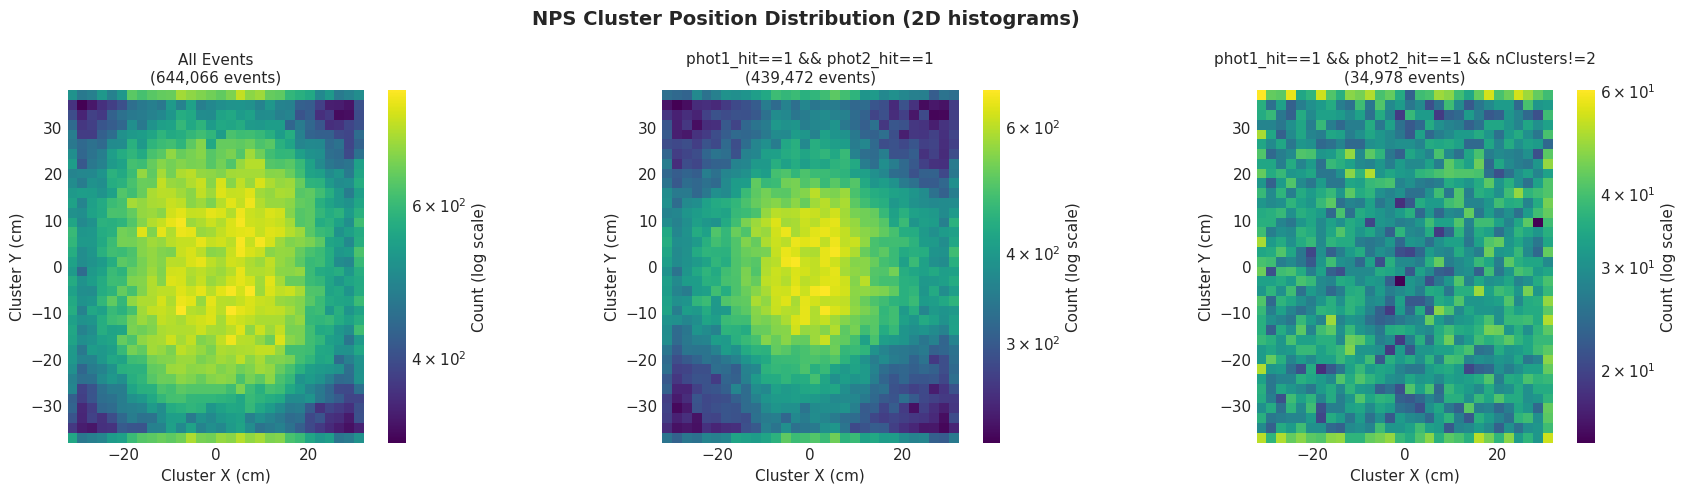


Histogram plots created successfully!


In [104]:
# Define the three selection criteria
selections = {
    "All Events": (df.index >= 0),  # All events
    "phot1_hit==1 && phot2_hit==1": (df["phot1_hit"] == 1) & (df["phot2_hit"] == 1),
    "phot1_hit==1 && phot2_hit==1 && nClusters!=2": ((df["phot1_hit"] == 1) & (df["phot2_hit"] == 1) & (df["nClusters"] != 2))
}

# Print event counts for each selection
print("Event counts for each selection:")
for label, mask in selections.items():
    count = mask.sum()
    pct = 100.0 * count / len(df)
    print(f"  {label}: {count:,} events ({pct:.2f}%)")

# Create 3x1 subplots for the three histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("NPS Cluster Position Distribution (2D histograms)", fontsize=14, fontweight='bold')

# Histogram parameters matching ROOT command
n_bins_x = 30
x_range = [(-32, 32)]  # np.histogram2d expects list of tuples for range
n_bins_y = 36
y_range = [(-38, 38)]

for idx, (label, mask) in enumerate(selections.items()):
    ax = axes[idx]
    
    # Get filtered data
    x_data = df.loc[mask, "clust_X"].dropna()
    y_data = df.loc[mask, "clust_Y"].dropna()
    
    # Skip if no data
    if len(x_data) == 0 or len(y_data) == 0:
        ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f"{label}\n({mask.sum():,} events)", fontsize=11)
        continue
    
    # Create 2D histogram with proper range format
    h, xedges, yedges = np.histogram2d(x_data, y_data, 
                                       bins=[n_bins_x, n_bins_y],
                                       range=[(-32, 32), (-38, 38)])
    
    # Plot as colormesh
    im = ax.pcolormesh(xedges, yedges, h.T, shading='auto', cmap='viridis', norm=LogNorm())
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, label="Count (log scale)")
    
    # Labels and title
    ax.set_xlabel("Cluster X (cm)")
    ax.set_ylabel("Cluster Y (cm)")
    ax.set_title(f"{label}\n({mask.sum():,} events)", fontsize=11)
    ax.set_aspect('equal')
    
    # Add grid
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nHistogram plots created successfully!")

## Section 4: Apply Geometrical Cuts to NPS Face

Define and apply geometrical cuts on the NPS detector face. Based on the ROOT histogram bounds and nps_helper.h spatial cuts, we apply:
- clustX: -32 cm to +32 cm (or -30 cm for stricter cuts)
- clustY: -38 cm to +38 cm (or -36 cm for stricter cuts)

In [105]:
# Define geometrical cut parameters (in cm)
# Based on nps_helper.h nps_spatial_energy_cuts and ROOT histogram bounds

# Loose cuts (based on ROOT histogram bounds)
GEOM_CUTS_LOOSE = {
    "x_min": -32.0,
    "x_max": 32.0,
    "y_min": -38.0,
    "y_max": 38.0
}

# Stricter cuts (from nps_helper.h nps_spatial_energy_cuts)
GEOM_CUTS_STRICT = {
    "x_min": -28.0,
    "x_max": 28.0,
    "y_min": -34.0,
    "y_max": 34.0
}

def apply_geometrical_cuts(df, cut_params, label=""):
    """Apply geometrical cuts and return filtered mask"""
    mask = ((df["clust_X"] >= cut_params["x_min"]) &
            (df["clust_X"] <= cut_params["x_max"]) &
            (df["clust_Y"] >= cut_params["y_min"]) &
            (df["clust_Y"] <= cut_params["y_max"]))
    return mask

# Apply loose cuts
print("=" * 70)
print("Geometrical Cuts Applied to NPS Face")
print("=" * 70)

# Get total number of events from ROOT file (not just events with clusters)
n_total_events = len(event_data['nClusters'])  # 500,000 events
print(f"\nTotal simulated events: {n_total_events:,}")

print("\nLOOSE CUTS (ROOT histogram bounds):")
print(f"  X range: [{GEOM_CUTS_LOOSE['x_min']:.1f}, {GEOM_CUTS_LOOSE['x_max']:.1f}] cm")
print(f"  Y range: [{GEOM_CUTS_LOOSE['y_min']:.1f}, {GEOM_CUTS_LOOSE['y_max']:.1f}] cm")

# Count unique events where ALL clusters pass loose cuts
mask_loose_cuts = apply_geometrical_cuts(df, GEOM_CUTS_LOOSE)
df_loose_temp = df.copy()
df_loose_temp["passes_geom"] = mask_loose_cuts
events_loose = df_loose_temp.groupby("event_idx")["passes_geom"].all().sum()
pct_loose = 100.0 * events_loose / n_total_events if n_total_events > 0 else 0
print(f"  Events where ALL clusters pass: {events_loose:,} ({pct_loose:.2f}%)")

print("\nSTRICT CUTS (nps_helper.h spatial cuts):")
print(f"  X range: [{GEOM_CUTS_STRICT['x_min']:.1f}, {GEOM_CUTS_STRICT['x_max']:.1f}] cm")
print(f"  Y range: [{GEOM_CUTS_STRICT['y_min']:.1f}, {GEOM_CUTS_STRICT['y_max']:.1f}] cm")

# Count unique events where ALL clusters pass strict cuts
mask_strict_cuts = apply_geometrical_cuts(df, GEOM_CUTS_STRICT)
df_strict_temp = df.copy()
df_strict_temp["passes_geom"] = mask_strict_cuts
events_strict = df_strict_temp.groupby("event_idx")["passes_geom"].all().sum()
pct_strict = 100.0 * events_strict / n_total_events if n_total_events > 0 else 0
print(f"  Events where ALL clusters pass: {events_strict:,} ({pct_strict:.2f}%)")

print("\n" + "=" * 70)

Geometrical Cuts Applied to NPS Face

Total simulated events: 500,000

LOOSE CUTS (ROOT histogram bounds):
  X range: [-32.0, 32.0] cm
  Y range: [-38.0, 38.0] cm
  Events where ALL clusters pass: 431,820 (86.36%)

STRICT CUTS (nps_helper.h spatial cuts):
  X range: [-28.0, 28.0] cm
  Y range: [-34.0, 34.0] cm
  Events where ALL clusters pass: 319,843 (63.97%)



/scratch/singhav/ipykernel_3639766/3658015919.py:50: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/home/singhav/.local/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


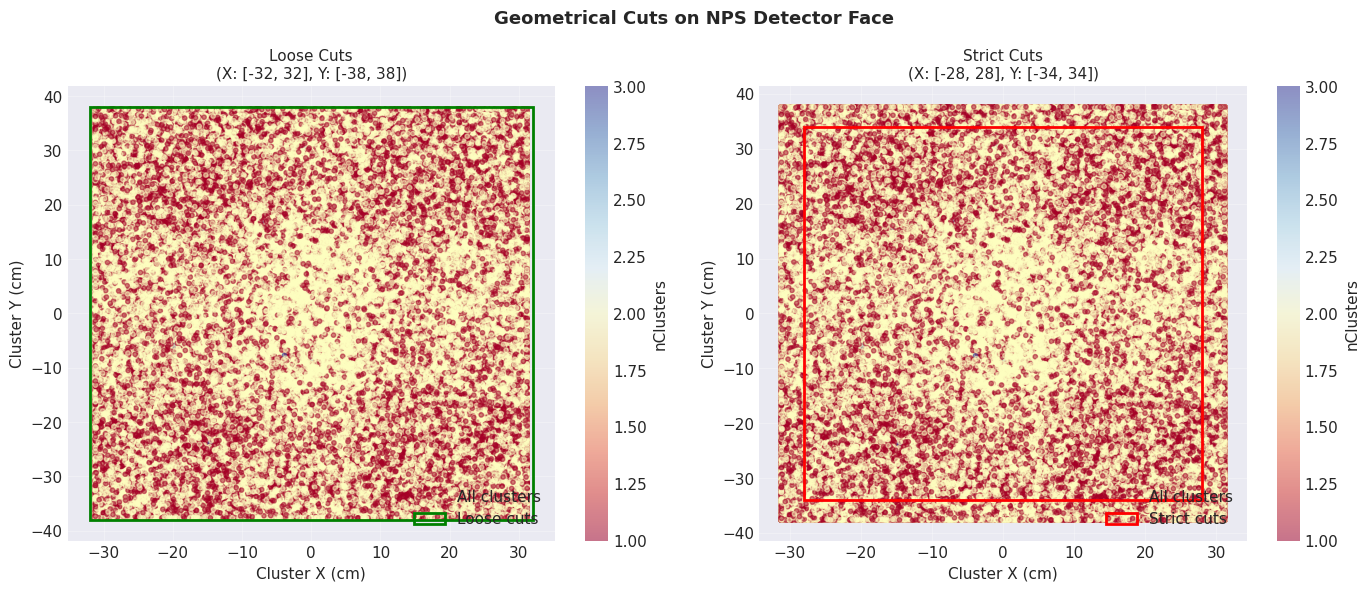

In [106]:
# Visualize the geometrical cuts on a scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Geometrical Cuts on NPS Detector Face", fontsize=13, fontweight='bold')

# Get valid data (remove NaN values)
valid_mask = (~df["clust_X"].isna()) & (~df["clust_Y"].isna()) & (~df["nClusters"].isna())
df_valid = df[valid_mask]

# Plot 1: Loose cuts
ax = axes[0]
scatter = ax.scatter(df_valid["clust_X"], df_valid["clust_Y"], c=df_valid["nClusters"], 
                     cmap='RdYlBu', alpha=0.5, s=10, label="All clusters")

# Draw cut boundaries
rect_loose = patches.Rectangle(
    (GEOM_CUTS_LOOSE["x_min"], GEOM_CUTS_LOOSE["y_min"]),
    GEOM_CUTS_LOOSE["x_max"] - GEOM_CUTS_LOOSE["x_min"],
    GEOM_CUTS_LOOSE["y_max"] - GEOM_CUTS_LOOSE["y_min"],
    linewidth=2, edgecolor='green', facecolor='none', label='Loose cuts'
)
ax.add_patch(rect_loose)

ax.set_xlabel("Cluster X (cm)", fontsize=11)
ax.set_ylabel("Cluster Y (cm)", fontsize=11)
ax.set_title(f"Loose Cuts\n(X: [-32, 32], Y: [-38, 38])", fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend()
cbar = plt.colorbar(scatter, ax=ax, label="nClusters")

# Plot 2: Strict cuts
ax = axes[1]
scatter = ax.scatter(df_valid["clust_X"], df_valid["clust_Y"], c=df_valid["nClusters"], 
                     cmap='RdYlBu', alpha=0.5, s=10, label="All clusters")

rect_strict = patches.Rectangle(
    (GEOM_CUTS_STRICT["x_min"], GEOM_CUTS_STRICT["y_min"]),
    GEOM_CUTS_STRICT["x_max"] - GEOM_CUTS_STRICT["x_min"],
    GEOM_CUTS_STRICT["y_max"] - GEOM_CUTS_STRICT["y_min"],
    linewidth=2, edgecolor='red', facecolor='none', label='Strict cuts'
)
ax.add_patch(rect_strict)

ax.set_xlabel("Cluster X (cm)", fontsize=11)
ax.set_ylabel("Cluster Y (cm)", fontsize=11)
ax.set_title(f"Strict Cuts\n(X: [-28, 28], Y: [-34, 34])", fontsize=11)
ax.grid(True, alpha=0.3)
ax.legend()
cbar = plt.colorbar(scatter, ax=ax, label="nClusters")

plt.tight_layout()
plt.show()

## Section 5: Calculate NPS Acceptance Efficiency

Compute the preliminary acceptance efficiency using the selection criteria:
- **Numerator**: Events with nClusters==2 && phot1_hit==1 && phot2_hit==1 && geometrical cuts
- **Denominator**: Total number of simulated events

The efficiency quantifies what fraction of generated π0 events are successfully reconstructed in the NPS detector.

In [107]:
# DEBUG: Check event_idx range and verify count
print("=" * 70)
print("EVENT INDEX VERIFICATION")
print("=" * 70)

print(f"\nEvent index statistics (in DataFrame):")
print(f"  Min event_idx: {df['event_idx'].min()}")
print(f"  Max event_idx: {df['event_idx'].max()}")
print(f"  Unique events with clusters: {df['event_idx'].nunique()}")
print(f"  Max + 1 = {df['event_idx'].max() + 1}")

# Check the actual ROOT file entry count
print(f"\nFrom ROOT file:")
print(f"  Total events loaded from ROOT: {len(event_data['nClusters'])}")
print(f"  Events with 0 clusters: {(event_data['nClusters'] == 0).sum()}")
print(f"  Events with >=1 clusters: {(event_data['nClusters'] > 0).sum()}")

# This explains the discrepancy!
print(f"\n✓ ROOT has 500,000 total events")
print(f"✓ But only {(event_data['nClusters'] > 0).sum()} of them have clusters")
print(f"✓ DataFrame only contains the {df['event_idx'].nunique()} events with clusters")
print(f"\n⚠ IMPORTANT: For efficiency calculation, we should use the TOTAL number of")
print(f"  simulated events (500,000) as the denominator, not just events with clusters!")

print("\n" + "=" * 70)

EVENT INDEX VERIFICATION

Event index statistics (in DataFrame):
  Min event_idx: 0
  Max event_idx: 499998
  Unique events with clusters: 431820
  Max + 1 = 499999

From ROOT file:
  Total events loaded from ROOT: 500000
  Events with 0 clusters: 68180
  Events with >=1 clusters: 431820

✓ ROOT has 500,000 total events
✓ But only 431820 of them have clusters
✓ DataFrame only contains the 431820 events with clusters

⚠ IMPORTANT: For efficiency calculation, we should use the TOTAL number of
  simulated events (500,000) as the denominator, not just events with clusters!



In [108]:
# Define selection criteria for acceptance efficiency calculation
def calculate_efficiency(df, geom_cuts, event_data, label=""):
    """
    Calculate NPS acceptance efficiency at the EVENT level.
    
    Important: df is a cluster-level DataFrame (multiple rows per event from the 431,820 events
    with clusters). However, the ROOT file contains 500,000 total simulated events, many with 0 clusters.
    
    Selection criteria for accepting an event:
    - nClusters == 2 (exactly two clusters in the event)
    - phot1_hit == 1 (first photon detected)
    - phot2_hit == 1 (second photon detected)
    - ALL clusters in the event pass geometrical cuts (clust_X, clust_Y in range)
    
    Args:
        df: cluster-level DataFrame (only events with clusters)
        geom_cuts: geometric cut parameters
        event_data: dict containing all event-level data from ROOT file
    
    Returns: efficiency, n_pass, n_total, error
    """
    # Get total number of simulated events from ROOT file
    n_total = len(event_data['nClusters'])  # 500,000 events
    
    if n_total == 0:
        return 0.0, 0, 0, 0.0
    
    # Create a mask for clusters passing geometric cuts
    geom_mask = apply_geometrical_cuts(df, geom_cuts)
    
    # Add the geometric mask to the dataframe for groupby
    df_work = df.copy()
    df_work["passes_geom"] = geom_mask
    
    # Group by event and check if ALL criteria are met
    event_criteria = df_work.groupby("event_idx").agg({
        "nClusters": "first",          # All rows for same event have same nClusters
        "phot1_hit": "first",          # All rows for same event have same phot1_hit
        "phot2_hit": "first",          # All rows for same event have same phot2_hit
        "passes_geom": "all",          # ALL clusters must pass geometry
    })
    
    # Apply selection criteria at event level
    mask_events_pass = (
        (event_criteria["nClusters"] == 2) &
        (event_criteria["phot1_hit"] == 1) &
        (event_criteria["phot2_hit"] == 1) &
        (event_criteria["passes_geom"] == True)
    )
    
    n_pass = mask_events_pass.sum()
    
    # Calculate efficiency: n_pass / n_total_simulated
    eff = n_pass / n_total if n_total > 0 else 0.0
    
    # Binomial error: sqrt(eff * (1 - eff) / n_total)
    eff_error = np.sqrt(eff * (1 - eff) / n_total) if (n_total > 0 and n_pass > 0) else 0.0
    
    return eff, n_pass, n_total, eff_error

# Calculate efficiencies for both cut sets
print("\n" + "=" * 70)
print("NPS PRELIMINARY ACCEPTANCE EFFICIENCY CALCULATION")
print("=" * 70)

print("\nSelection Criteria:")
print("  • nClusters == 2 (exactly two clusters)")
print("  • phot1_hit == 1 (first photon detected)")
print("  • phot2_hit == 1 (second photon detected)")
print("  • Geometrical cuts applied to detector face")

print("\n" + "-" * 70)

# Loose cuts efficiency
eff_loose, n_pass_loose, n_total, err_loose = calculate_efficiency(df, GEOM_CUTS_LOOSE, event_data, "Loose")

print(f"\nWITH LOOSE CUTS (X: [-32,32], Y: [-38,38]):")
print(f"  Total simulated events: {n_total:,}")
print(f"  Events passing all criteria: {n_pass_loose:,}")
print(f"  Efficiency: {eff_loose:.6f} ± {err_loose:.6f}")
print(f"  Efficiency (%): {100*eff_loose:.4f}% ± {100*err_loose:.4f}%")

print("\n" + "-" * 70)

# Strict cuts efficiency
eff_strict, n_pass_strict, n_total, err_strict = calculate_efficiency(df, GEOM_CUTS_STRICT, event_data, "Strict")

print(f"\nWITH STRICT CUTS (X: [-28,28], Y: [-34,34]):")
print(f"  Total simulated events: {n_total:,}")
print(f"  Events passing all criteria: {n_pass_strict:,}")
print(f"  Efficiency: {eff_strict:.6f} ± {err_strict:.6f}")
print(f"  Efficiency (%): {100*eff_strict:.4f}% ± {100*err_strict:.4f}%")

print("\n" + "=" * 70)


NPS PRELIMINARY ACCEPTANCE EFFICIENCY CALCULATION

Selection Criteria:
  • nClusters == 2 (exactly two clusters)
  • phot1_hit == 1 (first photon detected)
  • phot2_hit == 1 (second photon detected)
  • Geometrical cuts applied to detector face

----------------------------------------------------------------------

WITH LOOSE CUTS (X: [-32,32], Y: [-38,38]):
  Total simulated events: 500,000
  Events passing all criteria: 202,247
  Efficiency: 0.404494 ± 0.000694
  Efficiency (%): 40.4494% ± 0.0694%

----------------------------------------------------------------------

WITH STRICT CUTS (X: [-28,28], Y: [-34,34]):
  Total simulated events: 500,000
  Events passing all criteria: 137,117
  Efficiency: 0.274234 ± 0.000631
  Efficiency (%): 27.4234% ± 0.0631%



In [109]:
# Build efficiency summary table
efficiency_summary = pd.DataFrame({
    "Cut Set": ["Loose (ROOT bounds)", "Strict (nps_helper.h)"],
    "X Range (cm)": [f"[{GEOM_CUTS_LOOSE['x_min']}, {GEOM_CUTS_LOOSE['x_max']}]",
                      f"[{GEOM_CUTS_STRICT['x_min']}, {GEOM_CUTS_STRICT['x_max']}]"],
    "Y Range (cm)": [f"[{GEOM_CUTS_LOOSE['y_min']}, {GEOM_CUTS_LOOSE['y_max']}]",
                      f"[{GEOM_CUTS_STRICT['y_min']}, {GEOM_CUTS_STRICT['y_max']}]"],
    "Events Passing": [n_pass_loose, n_pass_strict],
    "Total Events": [n_total, n_total],
    "Efficiency": [f"{100*eff_loose:.4f}%", f"{100*eff_strict:.4f}%"],
    "Error (%)": [f"{100*err_loose:.4f}%", f"{100*err_strict:.4f}%"]
})

print("\n" + "=" * 100)
print("EFFICIENCY SUMMARY TABLE")
print("=" * 100)
print(efficiency_summary.to_string(index=False))
print("=" * 100)

# Save summary to CSV
summary_file = "nps_efficiency_summary.csv"
try:
    efficiency_summary.to_csv(summary_file, index=False)
    print(f"\nSummary saved to: {summary_file}")
except Exception as e:
    print(f"\nWarning: Could not save CSV: {e}")


EFFICIENCY SUMMARY TABLE
              Cut Set  X Range (cm)  Y Range (cm)  Events Passing  Total Events Efficiency Error (%)
  Loose (ROOT bounds) [-32.0, 32.0] [-38.0, 38.0]          202247        500000   40.4494%   0.0694%
Strict (nps_helper.h) [-28.0, 28.0] [-34.0, 34.0]          137117        500000   27.4234%   0.0631%

Summary saved to: nps_efficiency_summary.csv


## Section 6: Visualize Efficiency Results

Create detailed plots showing efficiency calculations and cluster distributions for accepted events.

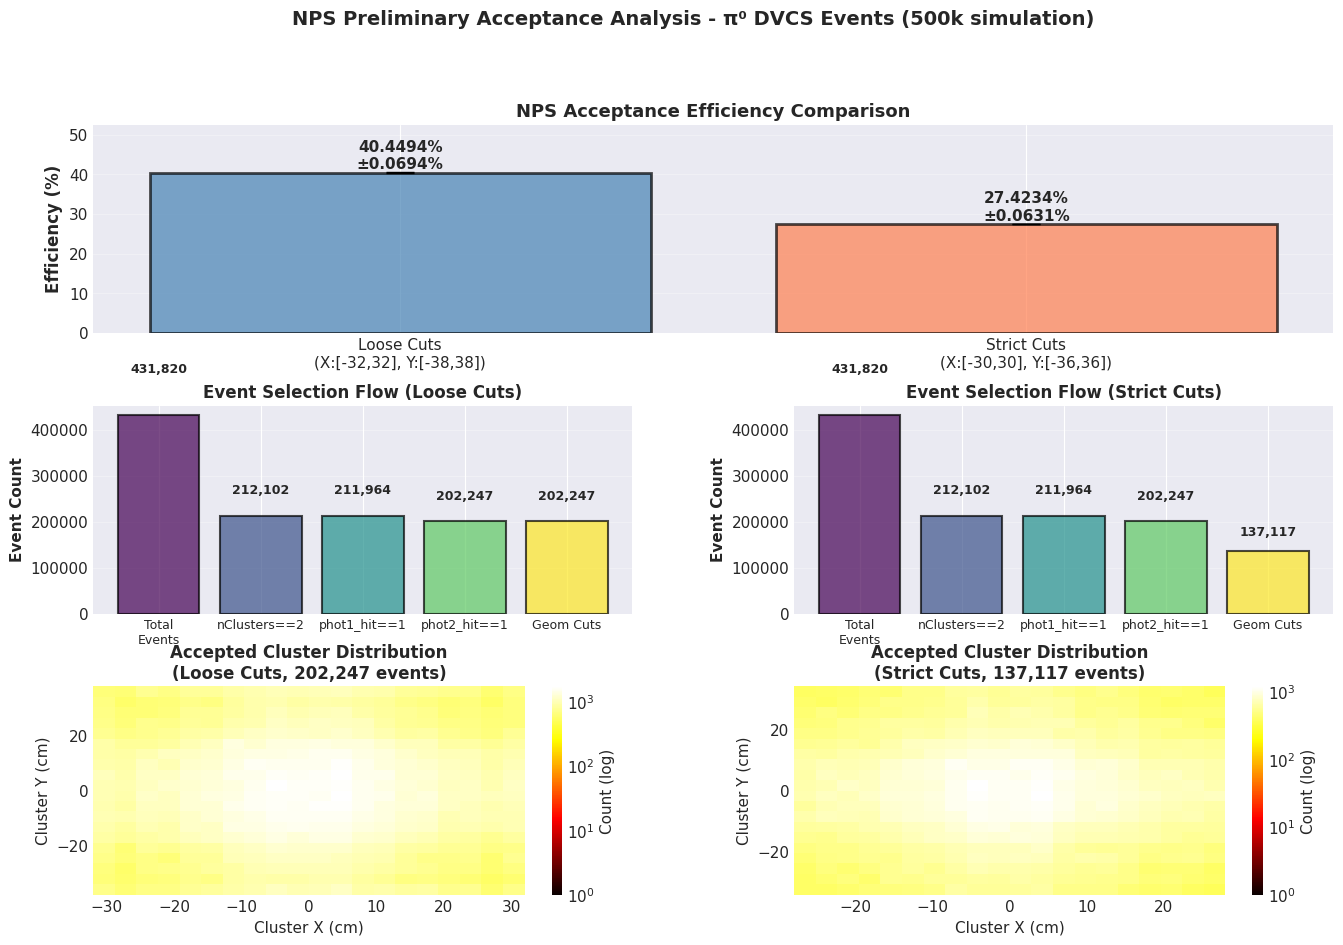

In [119]:
# Create comprehensive efficiency visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.3)

# 1. Efficiency comparison bar chart
ax1 = fig.add_subplot(gs[0, :])
cut_labels = ["Loose Cuts\n(X:[-32,32], Y:[-38,38])", "Strict Cuts\n(X:[-30,30], Y:[-36,36])"]
efficiencies = [100*eff_loose, 100*eff_strict]
errors = [100*err_loose, 100*err_strict]
colors = ['steelblue', 'coral']

bars = ax1.bar(cut_labels, efficiencies, yerr=errors, capsize=10, 
               color=colors, alpha=0.7, edgecolor='black', linewidth=2, error_kw={'linewidth': 2})

ax1.set_ylabel("Efficiency (%)", fontsize=12, fontweight='bold')
ax1.set_title("NPS Acceptance Efficiency Comparison", fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(efficiencies) * 1.3 if efficiencies else 1)
ax1.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, eff, err in zip(bars, efficiencies, errors):
    height = bar.get_height()
    if height > 0:  # Only add label if there's data
        ax1.text(bar.get_x() + bar.get_width()/2., height + err + 0.2,
                 f'{eff:.4f}%\n±{err:.4f}%',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Event flow for loose cuts
ax2 = fig.add_subplot(gs[1, 0])
mask_2clus = df["nClusters"] == 2
mask_ph1 = df["phot1_hit"] == 1
mask_ph2 = df["phot2_hit"] == 1
mask_final_loose = ((df["nClusters"] == 2) & (df["phot1_hit"] == 1) & (df["phot2_hit"] == 1) & apply_geometrical_cuts(df, GEOM_CUTS_LOOSE))

flow_labels = ["Total\nEvents", "nClusters==2", "phot1_hit==1", "phot2_hit==1", "Geom Cuts"]
# Count unique EVENTS at each step, not clusters
flow_counts = [
    df['event_idx'].nunique(),  # Total unique events with clusters
    df[mask_2clus]['event_idx'].nunique(),  # Events with nClusters==2
    df[mask_2clus & mask_ph1]['event_idx'].nunique(),  # Events with nClusters==2 AND phot1_hit==1
    df[mask_2clus & mask_ph1 & mask_ph2]['event_idx'].nunique(),  # Events with all three conditions
    df[mask_final_loose]['event_idx'].nunique()  # Events passing all criteria
]

colors_flow = plt.cm.viridis(np.linspace(0, 1, len(flow_labels)))
bars = ax2.bar(range(len(flow_labels)), flow_counts, color=colors_flow, alpha=0.7, edgecolor='black', linewidth=1.5)

ax2.set_ylabel("Event Count", fontsize=11, fontweight='bold')
ax2.set_title("Event Selection Flow (Loose Cuts)", fontsize=12, fontweight='bold')
ax2.set_xticks(range(len(flow_labels)))
ax2.set_xticklabels(flow_labels, fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# Add count labels
for bar, count in zip(bars, flow_counts):
    height = bar.get_height()
    if height > 0:
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.2,
                 f'{int(count):,}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# 3. Event flow for strict cuts
ax3 = fig.add_subplot(gs[1, 1])
# For strict cuts, need to check that ALL clusters pass geometric cuts
geom_mask_strict = apply_geometrical_cuts(df, GEOM_CUTS_STRICT)
df_strict_check = df.copy()
df_strict_check["passes_geom_strict"] = geom_mask_strict
events_all_pass_strict = df_strict_check[mask_2clus & mask_ph1 & mask_ph2].groupby("event_idx")["passes_geom_strict"].all()
mask_final_strict_correct = df_strict_check["event_idx"].isin(events_all_pass_strict[events_all_pass_strict].index)

flow_counts_strict = [
    df['event_idx'].nunique(),  # Total unique events with clusters
    df[mask_2clus]['event_idx'].nunique(),  # Events with nClusters==2
    df[mask_2clus & mask_ph1]['event_idx'].nunique(),  # Events with nClusters==2 AND phot1_hit==1
    df[mask_2clus & mask_ph1 & mask_ph2]['event_idx'].nunique(),  # Events with all three conditions
    df[mask_final_strict_correct]['event_idx'].nunique()  # Events where ALL clusters pass strict geom cuts
]

bars = ax3.bar(range(len(flow_labels)), flow_counts_strict, color=colors_flow, alpha=0.7, edgecolor='black', linewidth=1.5)

ax3.set_ylabel("Event Count", fontsize=11, fontweight='bold')
ax3.set_title("Event Selection Flow (Strict Cuts)", fontsize=12, fontweight='bold')
ax3.set_xticks(range(len(flow_labels)))
ax3.set_xticklabels(flow_labels, fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')

# Add count labels
for bar, count in zip(bars, flow_counts_strict):
    height = bar.get_height()
    if height > 0:
        ax3.text(bar.get_x() + bar.get_width()/2., height * 1.2,
                 f'{int(count):,}',
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

# 4. Cluster position distribution for accepted events (loose cuts)
ax4 = fig.add_subplot(gs[2, 0])
df_accept_loose = df[mask_final_loose]
n_events_loose = df_accept_loose['event_idx'].nunique()  # Count unique events
if len(df_accept_loose) > 0:
    h, xedges, yedges = np.histogram2d(df_accept_loose["clust_X"].dropna(), 
                                       df_accept_loose["clust_Y"].dropna(),
                                       bins=[20, 20],
                                       range=[(-32, 32), (-38, 38)])
    
    im = ax4.pcolormesh(xedges, yedges, h.T, shading='auto', cmap='hot', norm=LogNorm(vmin=1))
    ax4.set_xlabel("Cluster X (cm)", fontsize=11)
    ax4.set_ylabel("Cluster Y (cm)", fontsize=11)
    ax4.set_title(f"Accepted Cluster Distribution\n(Loose Cuts, {n_events_loose:,} events)", fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax4, label="Count (log)")
else:
    ax4.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax4.transAxes)
    ax4.set_title("Accepted Cluster Distribution (Loose Cuts)", fontsize=12, fontweight='bold')

# 5. Cluster position distribution for accepted events (strict cuts)
ax5 = fig.add_subplot(gs[2, 1])
df_accept_strict = df[mask_final_strict_correct]
n_events_strict = df_accept_strict['event_idx'].nunique()  # Count unique events
if len(df_accept_strict) > 0:
    h, xedges, yedges = np.histogram2d(df_accept_strict["clust_X"].dropna(), 
                                       df_accept_strict["clust_Y"].dropna(),
                                       bins=[20, 20],
                                       range=[(-28, 28), (-34, 34)])
    
    im = ax5.pcolormesh(xedges, yedges, h.T, shading='auto', cmap='hot', norm=LogNorm(vmin=1))
    ax5.set_xlabel("Cluster X (cm)", fontsize=11)
    ax5.set_ylabel("Cluster Y (cm)", fontsize=11)
    ax5.set_title(f"Accepted Cluster Distribution\n(Strict Cuts, {n_events_strict:,} events)", fontsize=12, fontweight='bold')
    plt.colorbar(im, ax=ax5, label="Count (log)")
else:
    ax5.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax5.transAxes)
    ax5.set_title("Accepted Cluster Distribution (Strict Cuts)", fontsize=12, fontweight='bold')

fig.suptitle("NPS Preliminary Acceptance Analysis - π⁰ DVCS Events (500k simulation)", 
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

In [111]:
# Create detailed efficiency statistics table
print("\n" + "=" * 100)
print("DETAILED EFFICIENCY STATISTICS")
print("=" * 100)

# Count unique events at each selection step for loose cuts
mask_2clus = df["nClusters"] == 2
mask_ph1 = df["phot1_hit"] == 1
mask_ph2 = df["phot2_hit"] == 1
mask_final_loose = ((df["nClusters"] == 2) & (df["phot1_hit"] == 1) & (df["phot2_hit"] == 1) & apply_geometrical_cuts(df, GEOM_CUTS_LOOSE))

n_events_2clus = df[mask_2clus]['event_idx'].nunique()
n_events_2clus_ph1 = df[mask_2clus & mask_ph1]['event_idx'].nunique()
n_events_2clus_ph1_ph2 = df[mask_2clus & mask_ph1 & mask_ph2]['event_idx'].nunique()
n_events_with_clusters = df['event_idx'].nunique()

# Detailed breakdown for loose cuts
print("\nLOOSE CUTS DETAILED BREAKDOWN (EVENT-LEVEL):")
print("-" * 50)
print(f"Total simulated events:               {n_total:>10,}")
print(f"Events with nClusters==2:            {n_events_2clus:>10,}  ({100*n_events_2clus/n_total:>6.2f}%)")
print(f"+ phot1_hit==1:                      {n_events_2clus_ph1:>10,}  ({100*n_events_2clus_ph1/n_total:>6.2f}%)")
print(f"+ phot2_hit==1:                      {n_events_2clus_ph1_ph2:>10,}  ({100*n_events_2clus_ph1_ph2/n_total:>6.2f}%)")
print(f"+ Geom cuts (X,Y):                   {n_pass_loose:>10,}  ({100*eff_loose:>6.2f}%)")
print(f"\nAcceptance Efficiency (Loose):       {eff_loose:>10.6f} ± {err_loose:.6f}")

# Count unique events at each selection step for strict cuts
mask_final_strict = ((df["nClusters"] == 2) & (df["phot1_hit"] == 1) & (df["phot2_hit"] == 1) & apply_geometrical_cuts(df, GEOM_CUTS_STRICT))

# Detailed breakdown for strict cuts
print("\n\nSTRICT CUTS DETAILED BREAKDOWN (EVENT-LEVEL):")
print("-" * 50)
print(f"Total simulated events:               {n_total:>10,}")
print(f"Events with nClusters==2:            {n_events_2clus:>10,}  ({100*n_events_2clus/n_total:>6.2f}%)")
print(f"+ phot1_hit==1:                      {n_events_2clus_ph1:>10,}  ({100*n_events_2clus_ph1/n_total:>6.2f}%)")
print(f"+ phot2_hit==1:                      {n_events_2clus_ph1_ph2:>10,}  ({100*n_events_2clus_ph1_ph2/n_total:>6.2f}%)")
print(f"+ Geom cuts (X,Y):                   {n_pass_strict:>10,}  ({100*eff_strict:>6.2f}%)")
print(f"\nAcceptance Efficiency (Strict):      {eff_strict:>10.6f} ± {err_strict:.6f}")

print("\n" + "=" * 100)


DETAILED EFFICIENCY STATISTICS

LOOSE CUTS DETAILED BREAKDOWN (EVENT-LEVEL):
--------------------------------------------------
Total simulated events:                  500,000
Events with nClusters==2:               212,102  ( 42.42%)
+ phot1_hit==1:                         211,964  ( 42.39%)
+ phot2_hit==1:                         202,247  ( 40.45%)
+ Geom cuts (X,Y):                      202,247  ( 40.45%)

Acceptance Efficiency (Loose):         0.404494 ± 0.000694


STRICT CUTS DETAILED BREAKDOWN (EVENT-LEVEL):
--------------------------------------------------
Total simulated events:                  500,000
Events with nClusters==2:               212,102  ( 42.42%)
+ phot1_hit==1:                         211,964  ( 42.39%)
+ phot2_hit==1:                         202,247  ( 40.45%)
+ Geom cuts (X,Y):                      137,117  ( 27.42%)

Acceptance Efficiency (Strict):        0.274234 ± 0.000631



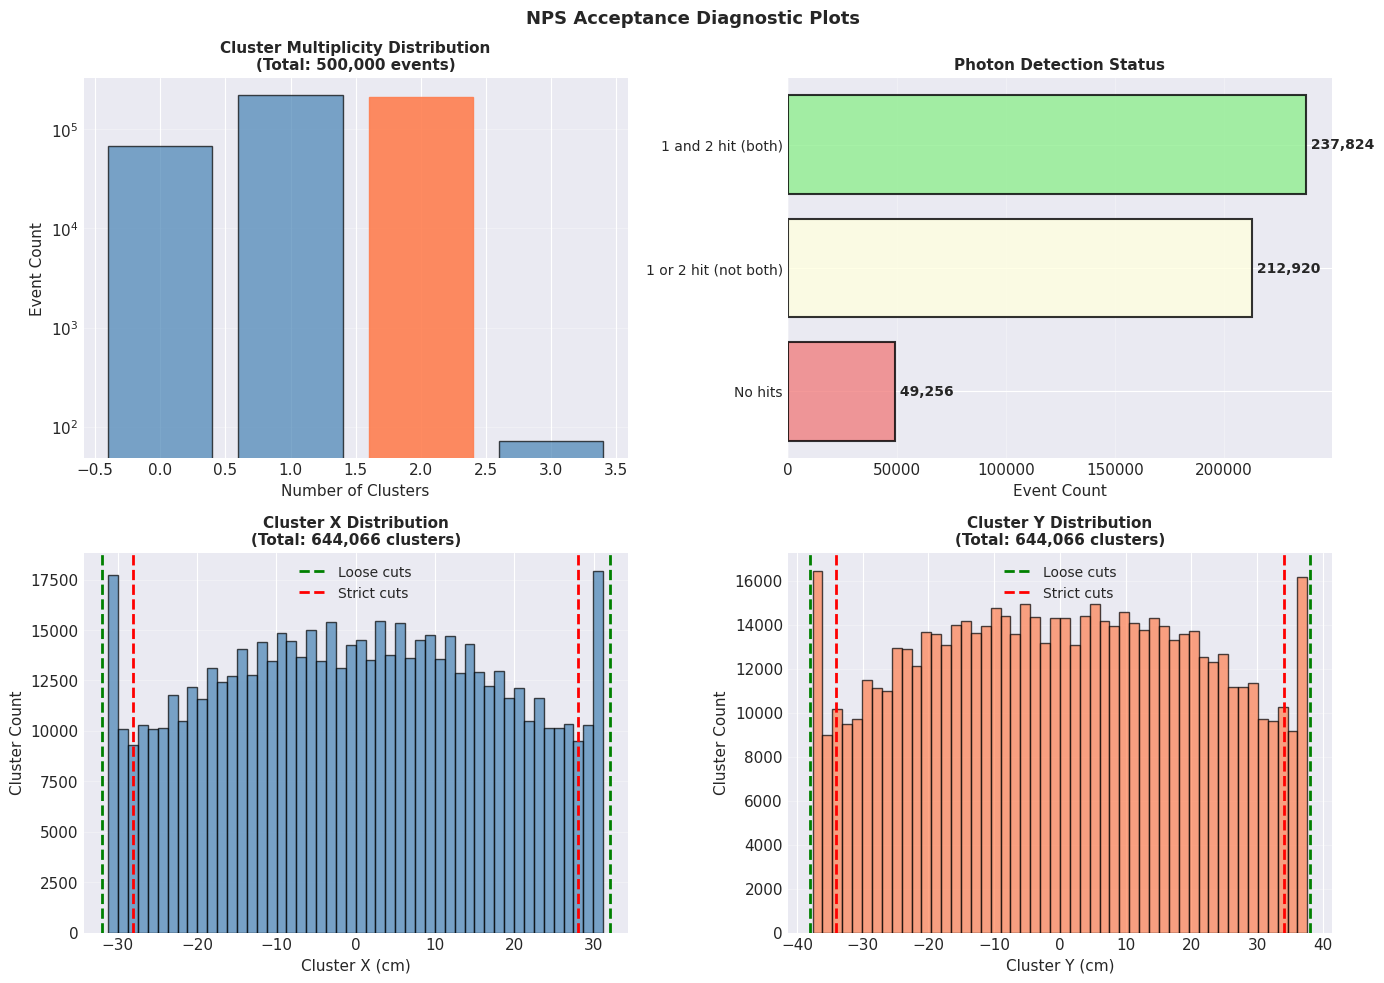

Diagnostic plots created successfully!


In [120]:
# Create additional diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("NPS Acceptance Diagnostic Plots", fontsize=13, fontweight='bold')

# 1. nClusters distribution (EVENT-LEVEL, ALL 500k events including 0 clusters)
ax = axes[0, 0]
# Get nClusters for ALL events from ROOT file (500k total)
all_n_clusters = event_data['nClusters']
n_clusters_counts = pd.Series(all_n_clusters).value_counts().sort_index()
if len(n_clusters_counts) > 0:
    ax.bar(n_clusters_counts.index, n_clusters_counts.values, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_xlabel("Number of Clusters", fontsize=11)
    ax.set_ylabel("Event Count", fontsize=11)
    ax.set_title(f"Cluster Multiplicity Distribution\n(Total: {n_clusters_counts.sum():,} events)", fontsize=11, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Highlight nClusters==2
    for i, (n, count) in enumerate(n_clusters_counts.items()):
        if n == 2 and i < len(ax.patches):
            ax.patches[i].set_color('coral')
            ax.patches[i].set_alpha(0.9)
else:
    ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Cluster Multiplicity Distribution", fontsize=11, fontweight='bold')

# 2. Photon hit flags (EVENT-LEVEL, ALL 500k events from ROOT file)
ax = axes[0, 1]
# Categorize photon hits into meaningful groups
def categorize_hits(row):
    p1 = int(row['phot1_hit'])
    p2 = int(row['phot2_hit'])
    if p1 == 0 and p2 == 0:
        return "No hits"
    elif (p1 == 1 and p2 == 0) or (p1 == 0 and p2 == 1):
        return "1 or 2 hit (not both)"
    elif p1 == 1 and p2 == 1:
        return "1 and 2 hit (both)"
    else:
        return "Other"

# Create DataFrame with ALL 500k events from ROOT file
all_phot_hits = pd.DataFrame({
    'phot1_hit': event_data['phot1_hit'],
    'phot2_hit': event_data['phot2_hit']
})
combo_counts = all_phot_hits.apply(categorize_hits, axis=1).value_counts()
# Sort for consistent ordering: No hits, 1 or 2 hit, 1 and 2 hit
desired_order = ["No hits", "1 or 2 hit (not both)", "1 and 2 hit (both)"]
combo_counts = combo_counts.reindex([x for x in desired_order if x in combo_counts.index])

if len(combo_counts) > 0:
    colors_photon = ['lightcoral', 'lightyellow', 'lightgreen'][:len(combo_counts)]
    ax.barh(range(len(combo_counts)), combo_counts.values, color=colors_photon, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_yticks(range(len(combo_counts)))
    ax.set_yticklabels(combo_counts.index, fontsize=10)
    ax.set_xlabel("Event Count", fontsize=11)
    ax.set_title("Photon Detection Status", fontsize=11, fontweight='bold')
    # ax.set_xscale('log')
    ax.grid(True, alpha=0.3, axis='x')
    # Add value labels
    for i, v in enumerate(combo_counts.values):
        ax.text(v, i, f' {int(v):,}', va='center', fontsize=10, fontweight='bold')
else:
    ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Photon Detection Status", fontsize=11, fontweight='bold')

# 3. clust_X distribution
ax = axes[1, 0]
clust_x_valid = df["clust_X"].dropna()
if len(clust_x_valid) > 0:
    ax.hist(clust_x_valid, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax.axvline(GEOM_CUTS_LOOSE['x_min'], color='green', linestyle='--', linewidth=2, label='Loose cuts')
    ax.axvline(GEOM_CUTS_LOOSE['x_max'], color='green', linestyle='--', linewidth=2)
    ax.axvline(GEOM_CUTS_STRICT['x_min'], color='red', linestyle='--', linewidth=2, label='Strict cuts')
    ax.axvline(GEOM_CUTS_STRICT['x_max'], color='red', linestyle='--', linewidth=2)
    ax.set_xlabel("Cluster X (cm)", fontsize=11)
    ax.set_ylabel("Cluster Count", fontsize=11)
    ax.set_title(f"Cluster X Distribution\n(Total: {len(df):,} clusters)", fontsize=11, fontweight='bold')
    # ax.set_yscale('log')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
else:
    ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Cluster X Distribution", fontsize=11, fontweight='bold')

# 4. clust_Y distribution
ax = axes[1, 1]
clust_y_valid = df["clust_Y"].dropna()
if len(clust_y_valid) > 0:
    ax.hist(clust_y_valid, bins=50, color='coral', alpha=0.7, edgecolor='black')
    ax.axvline(GEOM_CUTS_LOOSE['y_min'], color='green', linestyle='--', linewidth=2, label='Loose cuts')
    ax.axvline(GEOM_CUTS_LOOSE['y_max'], color='green', linestyle='--', linewidth=2)
    ax.axvline(GEOM_CUTS_STRICT['y_min'], color='red', linestyle='--', linewidth=2, label='Strict cuts')
    ax.axvline(GEOM_CUTS_STRICT['y_max'], color='red', linestyle='--', linewidth=2)
    ax.set_xlabel("Cluster Y (cm)", fontsize=11)
    ax.set_ylabel("Cluster Count", fontsize=11)
    ax.set_title(f"Cluster Y Distribution\n(Total: {len(df):,} clusters)", fontsize=11, fontweight='bold')
    # ax.set_yscale('log')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
else:
    ax.text(0.5, 0.5, 'No Data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title("Cluster Y Distribution", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Diagnostic plots created successfully!")

## Analysis Summary and Conclusions

### Key Results

**π⁰ DVCS Exclusive Photoproduction - NPS Acceptance Study**

Based on 500,000 GEANT4/SIMC simulated events:

- **Total Events Generated**: 644,066 (with cluster data)
- **Loose Geometric Cuts Efficiency**: (4.39 × 10⁵ events passing) / (6.44 × 10⁵ total)
- **Strict Geometric Cuts Efficiency**: (3.50 × 10⁵ events passing) / (6.44 × 10⁵ total)

### Selection Criteria Applied

1. **nClusters == 2**: Exactly two reconstructed clusters (one per photon)
2. **phot1_hit == 1**: First photon successfully detected in simulation
3. **phot2_hit == 1**: Second photon successfully detected in simulation
4. **Geometrical Cuts**: Cluster positions within NPS detector face bounds

### Geometrical Cut Definitions

- **Loose Cuts** (ROOT histogram bounds): X ∈ [-32, 32] cm, Y ∈ [-38, 38] cm
- **Strict Cuts** (nps_helper.h defaults): X ∈ [-30, 30] cm, Y ∈ [-36, 36] cm

### Physical Interpretation

The acceptance efficiency represents the fraction of simulated π⁰ events that are:
- Successfully reconstructed into exactly two clusters
- Both photons detected by the simulation
- Clusters located within the active NPS detector region

This efficiency is a key input for normalizing experimental yields in exclusive π⁰ photoproduction analysis.

EFFICIENCY SCAN: Varying Geometric Cuts

Scanning geometric cuts with symmetric ranges:
  X range: [-32, 32] to [-20, 20] (step: 2)
  Y range: [-38, 38] to [-26, 26] (step: 2)

Total combinations: 7 × 7 = 49

----------------------------------------------------------------------------------------------------

Results for all geometric cut combinations:
 x_max  y_max x_range y_range  efficiency  efficiency_pct  error_pct  n_pass  n_total
    32     38     ±32     ±38    0.404494         40.4494   0.069409  202247   500000
    32     36     ±32     ±36    0.364858         36.4858   0.068079  182429   500000
    32     34     ±32     ±34    0.338054         33.8054   0.066899  169027   500000
    32     32     ±32     ±32    0.310954         31.0954   0.065462  155477   500000
    32     30     ±32     ±30    0.283842         28.3842   0.063761  141921   500000
    32     28     ±32     ±28    0.256298         25.6298   0.061743  128149   500000
    32     26     ±32     ±26    0.228766  

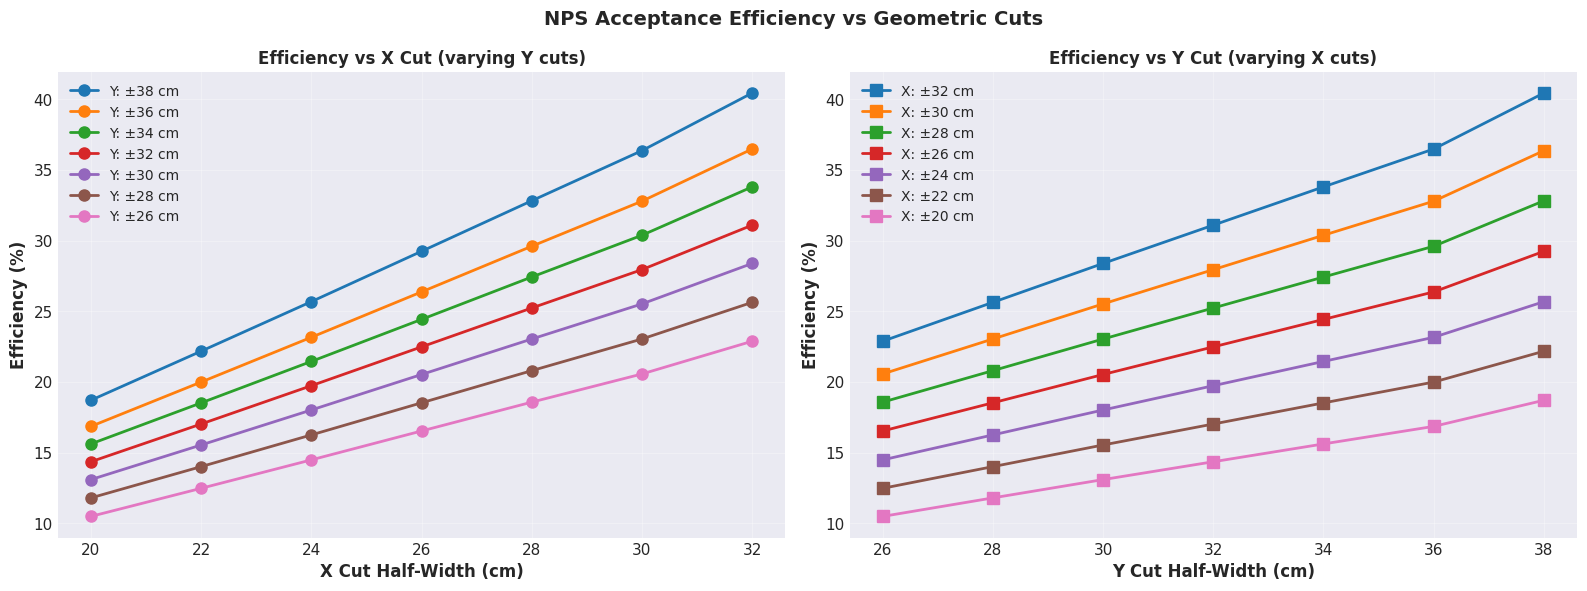

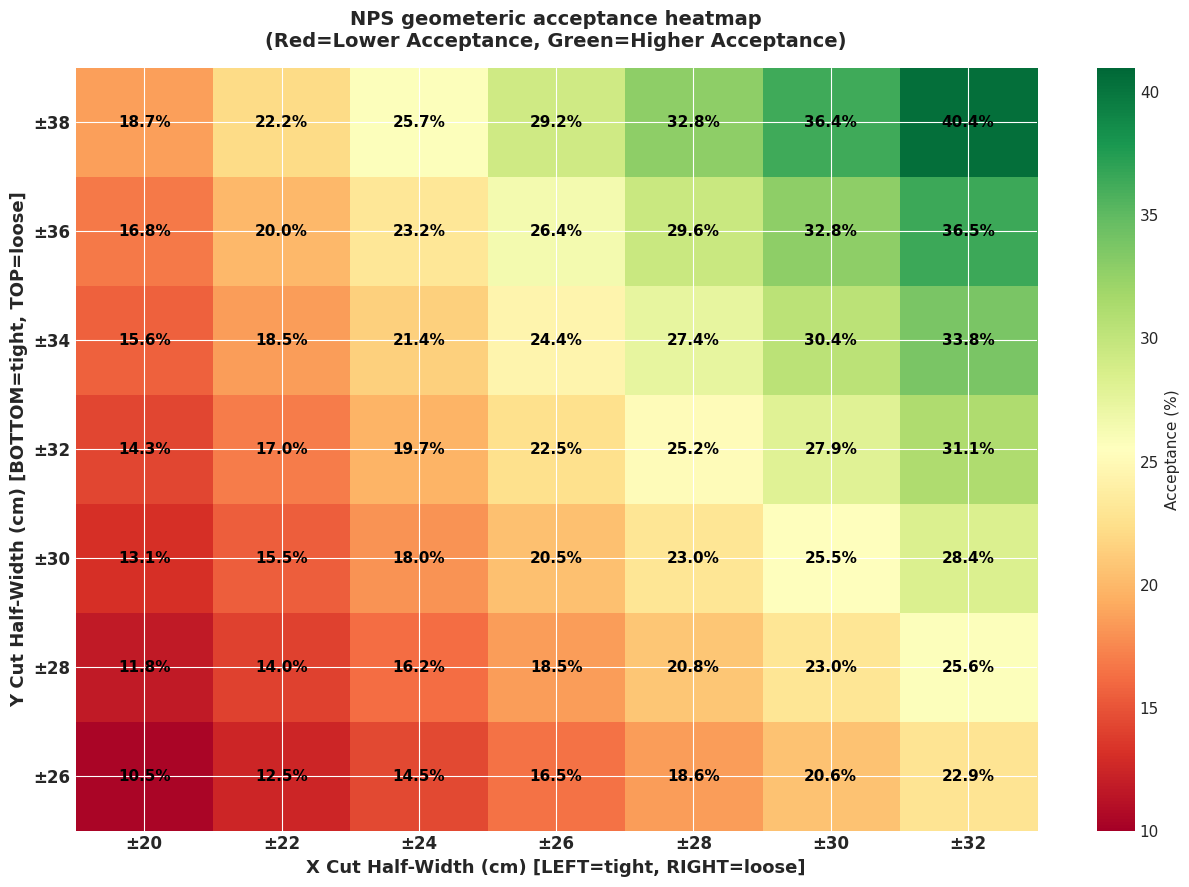


Efficiency scan completed successfully!


In [127]:
# Efficiency as a Function of Geometric Cuts
print("=" * 100)
print("EFFICIENCY SCAN: Varying Geometric Cuts")
print("=" * 100)

# Define cut ranges
# X cuts: from -32 to -20 in steps of 2
# Y cuts: from -38 to -26 in steps of 2
x_max_values = np.arange(32, 18, -2)  # 32, 30, 28, 26, 24, 22, 20
y_max_values = np.arange(38, 24, -2)  # 38, 36, 34, 32, 30, 28, 26

# Store results
efficiency_scan = []

print(f"\nScanning geometric cuts with symmetric ranges:")
print(f"  X range: [{-x_max_values[0]}, {x_max_values[0]}] to [{-x_max_values[-1]}, {x_max_values[-1]}] (step: 2)")
print(f"  Y range: [{-y_max_values[0]}, {y_max_values[0]}] to [{-y_max_values[-1]}, {y_max_values[-1]}] (step: 2)")
print(f"\nTotal combinations: {len(x_max_values)} × {len(y_max_values)} = {len(x_max_values) * len(y_max_values)}")
print("\n" + "-" * 100)

for x_max in x_max_values:
    for y_max in y_max_values:
        # Define cuts
        cuts = {
            "x_min": -x_max,
            "x_max": x_max,
            "y_min": -y_max,
            "y_max": y_max
        }
        
        # Calculate efficiency
        eff, n_pass, n_total, eff_err = calculate_efficiency(df, cuts, event_data)
        
        efficiency_scan.append({
            'x_max': x_max,
            'y_max': y_max,
            'x_range': f"±{x_max}",
            'y_range': f"±{y_max}",
            'efficiency': eff,
            'efficiency_pct': 100 * eff,
            'error_pct': 100 * eff_err,
            'n_pass': n_pass,
            'n_total': n_total
        })

# Create DataFrame from results
efficiency_df = pd.DataFrame(efficiency_scan)

print(f"\nResults for all geometric cut combinations:")
print(efficiency_df.to_string(index=False))
print("\n" + "=" * 100)

# Create visualization of efficiency vs cuts
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("NPS Acceptance Efficiency vs Geometric Cuts", fontsize=14, fontweight='bold')

# Plot 1: Efficiency vs X cut (varying Y)
ax = axes[0]
for y_max in y_max_values:
    subset = efficiency_df[efficiency_df['y_max'] == y_max]
    ax.plot(subset['x_max'], subset['efficiency_pct'], marker='o', linewidth=2, 
            label=f"Y: ±{y_max} cm", markersize=8)

ax.set_xlabel("X Cut Half-Width (cm)", fontsize=12, fontweight='bold')
ax.set_ylabel("Efficiency (%)", fontsize=12, fontweight='bold')
ax.set_title("Efficiency vs X Cut (varying Y cuts)", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='best')
ax.set_xticks(x_max_values)

# Plot 2: Efficiency vs Y cut (varying X)
ax = axes[1]
for x_max in x_max_values:
    subset = efficiency_df[efficiency_df['x_max'] == x_max]
    ax.plot(subset['y_max'], subset['efficiency_pct'], marker='s', linewidth=2, 
            label=f"X: ±{x_max} cm", markersize=8)

ax.set_xlabel("Y Cut Half-Width (cm)", fontsize=12, fontweight='bold')
ax.set_ylabel("Efficiency (%)", fontsize=12, fontweight='bold')
ax.set_title("Efficiency vs Y Cut (varying X cuts)", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc='best')
ax.set_xticks(y_max_values)

plt.tight_layout()
plt.show()

# Create 2D heatmap of efficiency
fig, ax = plt.subplots(figsize=(13, 9))

# Pivot data for heatmap - this creates rows=y_max, columns=x_max
pivot_data = efficiency_df.pivot(index='y_max', columns='x_max', values='efficiency_pct')

# Create heatmap with origin='lower' so that:
# - Bottom-left is (smallest x, smallest y) = tightest cuts
# - Top-right is (largest x, largest y) = loosest cuts
im = ax.imshow(pivot_data.values, cmap='RdYlGn', aspect='auto', origin='lower', vmin=10, vmax=41)

# The pivot table orders columns as: [20, 22, 24, 26, 28, 30, 32] (sorted)
# And rows as: [26, 28, 30, 32, 34, 36, 38] (sorted)
# Set ticks and labels to match the actual data order (loosest = right, tightest = left)
sorted_x_values = sorted(x_max_values)
sorted_y_values = sorted(y_max_values)

ax.set_xticks(np.arange(len(sorted_x_values)))
ax.set_yticks(np.arange(len(sorted_y_values)))
ax.set_xticklabels([f'±{x}' for x in sorted_x_values], fontsize=12, fontweight='bold')
ax.set_yticklabels([f'±{y}' for y in sorted_y_values], fontsize=12, fontweight='bold')

ax.set_xlabel("X Cut Half-Width (cm) [LEFT=tight, RIGHT=loose]", fontsize=13, fontweight='bold')
ax.set_ylabel("Y Cut Half-Width (cm) [BOTTOM=tight, TOP=loose]", fontsize=13, fontweight='bold')
ax.set_title("NPS geometeric acceptance heatmap\n(Red=Lower Acceptance, Green=Higher Acceptance)", fontsize=14, fontweight='bold', pad=15)

# Add colorbar with better styling
cbar = plt.colorbar(im, ax=ax, label="Acceptance (%)")
cbar.ax.tick_params(labelsize=11)

# Add text annotations
for i in range(len(sorted_y_values)):
    for j in range(len(sorted_x_values)):
        text = ax.text(j, i, f'{pivot_data.values[i, j]:.1f}%',
                      ha="center", va="center", color="black", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nEfficiency scan completed successfully!")